# <font color='blue'>Image denoising using an Ising model</font>

In this assignment, we'll denoise a corrupted image using Bayesian inference with a very simple prior.

### <font color='blue'>Preliminaries</font>

To begin with, you will need to have OpenCV installed (`pip install opencv-python`).

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import cv2
import math

This next routine loads in an image. We will be working with `noisy_bear.png`, which is a corrupted version of `original_bear.png`. The image is 62-by-62; we binarize it (to values -1 and +1) and then embed it in the center of a 64-by-64 image whose edges are padded with zeros.

In [12]:
# Subroutine for loading an image
# Any pixel with value >= 128 is set to +1
# Any pixel with value < 128 is set to -1
def load_image(filename):
  img = cv2.imread(filename,cv2.IMREAD_GRAYSCALE)
  img = img/255.0
  img[img>=0.5]=1.0
  img[img<0.5]=0.0
  img = img*2-1
  return img

# Load in both the degraded image and the original
img = load_image("noisy_bear.png")
gt = load_image("original_bear.png")
M,N = img.shape[0], img.shape[1]

# Create a version of img that is padded with zeros all around
padded_image = np.zeros((img.shape[0]+2, img.shape[1]+2)) #Padding image to make some computations easier 
padded_image[1:-1,1:-1] = img

### <font color='blue'>The probabilistic model</font>

Let $X$ denote the degraded image (of size $M \times N$) and $Y$ the original that we wish to reconstruct (warning: we used the opposite notation in lecture). We will posit a simple probabilistic model of the joint distribution of $(X,Y)$:


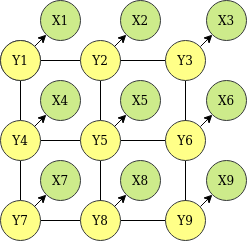


Let $p = (i,j)$ denote a position in the image and let $X_p = X(i,j), Y_p = Y(i,j)$ be the values of $X$ and $Y$ at that location. Recall that these values are -1 or +1. Write $p \sim q$ if $p,q$ are neighboring pixels; note that pixel $p = (i,j)$ has neighbors ${\mathcal{N}}(p) = \{ (i-1,j), (i+1,j), (i,j-1), (i,j+1)\}$. Then the probability of $X,Y$ is:

$$Pr(X,Y) \propto \prod\limits_{p \in [M] \times [N]} \phi(X_{p},Y_{p})\prod\limits_{p \sim q}\phi(Y_p, Y_q) $$ 

Notice that here all clique potentials are identical functions. We will use $\phi(u, v) = e^{uv}$.

### <font color='blue'>Sampling from the posterior</font>

We wish to sample from the <b>posterior distribution over $Y$ given $X$</b>. We'll do this using Gibbs sampling:

* We will initialize the recovered image with each pixel set uniformly to $\{-1,+1\}$
* We will then repeatedly choose a pixel $p$ to update and re-sample its value from $Pr(Y_p | X, Y_{\setminus p})$.

<font color='magenta'> To do:</font>
* <font color='magenta'>Implement the Gibbs sampler</font>
* <font color='magenta'>Show the intermediate reconstructed image at various stages along the way</font>
* <font color='magenta'>Estimate the posterior marginals $E[Y_p | X]$ and show a reconstructed image where each pixel is set to the sign of this value</font>

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import math

# (load_image function and X = load_image(...) assumed from notebook)

def gibbs_step(Y, X):
    """
    Performs one full sweep of Gibbs sampling.
    
    Y: Current state of the uncorrupted image (M x N)
    X: The noisy image (M x N)
    (eta and beta are 1.0 based on the notebook's model)
    """
    Y_new = np.copy(Y)
    M, N = Y.shape
    
    # Iterate over every pixel
    for i in range(M):
        for j in range(N):
            # Sum over neighbors, handling boundaries
            neighbors_sum = 0
            if i > 0:   neighbors_sum += Y_new[i-1, j] # Up
            if i < M-1: neighbors_sum += Y_new[i+1, j] # Down
            if j > 0:   neighbors_sum += Y_new[i, j-1] # Left
            if j < N-1: neighbors_sum += Y_new[i, j+1] # Right
            
            # E_p = eta * X_p + beta * neighbors_sum
            # From notebook model, eta=1 and beta=1
            E_p = X[i, j] + neighbors_sum
            
            # Prob of Y_p = +1
            # prob_plus_one = 1.0 / (1.0 + np.exp(-2.0 * E_p))
            # Use a numerically stable sigmoid:
            if E_p * 2 > 700: # Avoid overflow in exp
                prob_plus_one = 1.0
            elif E_p * 2 < -700:
                prob_plus_one = 0.0
            else:
                prob_plus_one = 1.0 / (1.0 + np.exp(-2.0 * E_p))

            # Sample from Bernoulli(prob_plus_one)
            if np.random.rand() < prob_plus_one:
                Y_new[i, j] = 1
            else:
                Y_new[i, j] = -1
                
    return Y_new

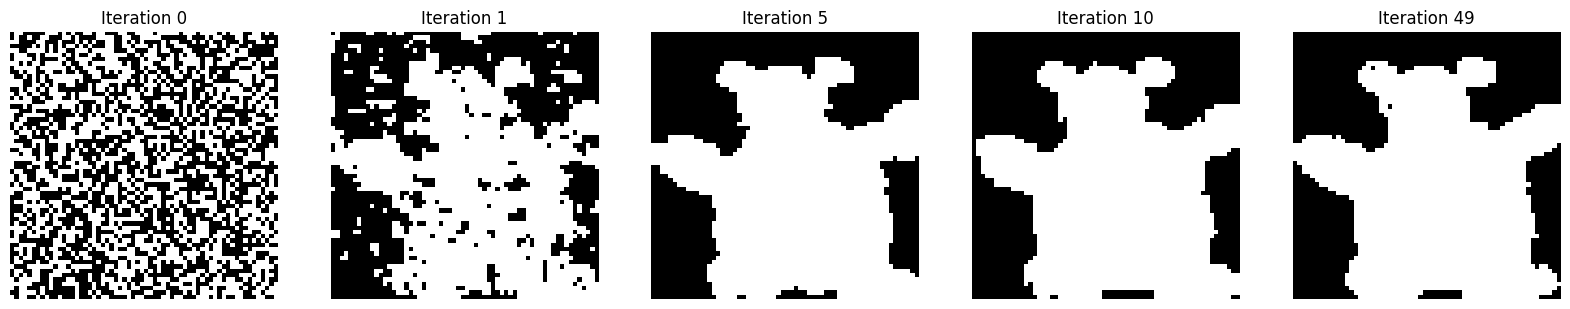

In [13]:
# --- Main loop (as would be in the notebook) ---
X = img
Y = np.random.choice([-1, 1], size=X.shape)
num_iterations = 50
images_to_show = []
iterations_to_save = [0, 1, 5, 10, 49]

for t in range(num_iterations):
    if t in iterations_to_save:
        images_to_show.append(np.copy(Y))
    Y = gibbs_step(Y, X)

# --- Plotting (as would be in the notebook) ---
fig, axes = plt.subplots(1, len(images_to_show), figsize=(20, 4))
for ax, img, t in zip(axes, images_to_show, iterations_to_save):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Iteration {t}')
    ax.axis('off')
plt.show()

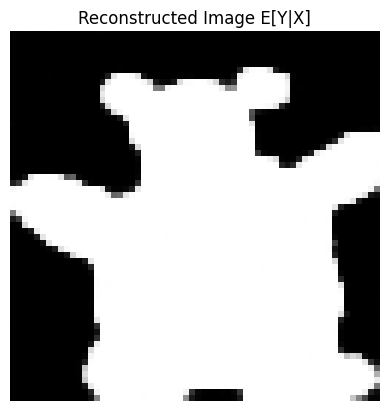

In [14]:
def get_posterior_mean(Y, X, burn_in, num_samples):
    M, N = X.shape
    Y_samples_sum = np.zeros((M, N), dtype=float)
    
    # Run the chain
    for t in range(burn_in + num_samples):
        Y = gibbs_step(Y, X)
        
        # After burn-in, start collecting samples
        if t >= burn_in:
            Y_samples_sum += Y
            
    # Compute the average
    posterior_mean = Y_samples_sum / num_samples
    return posterior_mean

X= img
Y_init = np.random.choice([-1, 1], size=X.shape)
posterior_mean_image = get_posterior_mean(Y_init, X, 
                                            burn_in=50, 
                                            num_samples=200)

# plot
plt.imshow(posterior_mean_image, cmap='gray', vmin=-1, vmax=1)
plt.title('Reconstructed Image E[Y|X]')
plt.axis('off')
plt.show()

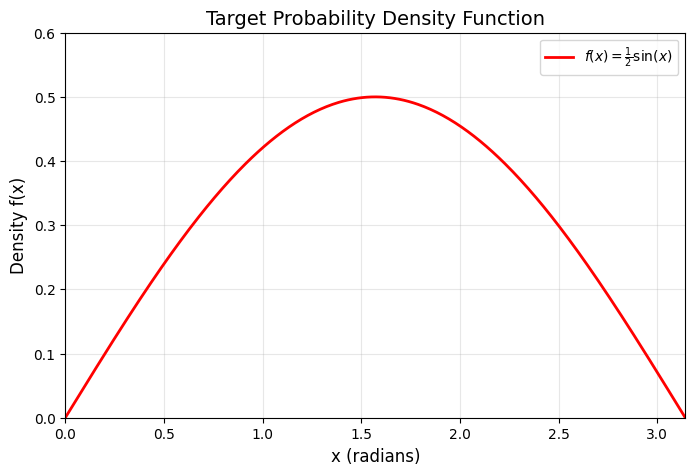

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the function and domain
f = lambda x: 0.5 * np.sin(x)
x_domain = np.linspace(0, np.pi, 400)
y_values = f(x_domain)

# 2. Create a professional plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_domain, y_values, 'r-', linewidth=2, 
        label=r'$f(x) = \frac{1}{2}\sin(x)$')

# 3. Add labels, title, and grid
ax.set_xlabel('x (radians)', fontsize=12)
ax.set_ylabel('Density f(x)', fontsize=12)
ax.set_title('Target Probability Density Function', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, np.pi)
ax.set_ylim(0, 0.6) # Max is 0.5, give a little space

# 4. Save and show the plot
plt.savefig('q6a_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
import numpy as np

# Set seed for reproducible results
np.random.seed(42)

N_ACCEPT = 10000
accepted_samples = []
total_draws = 0

#Parameters from 6(b)
f = lambda x: 0.5 * np.sin(x)
g = lambda x: 1.0 / np.pi
M = np.pi / 2.0

# Loop until we have 10,000 accepted samples
while len(accepted_samples) < N_ACCEPT:
    total_draws += 1
    
    # 1. Sample x from g(x) = Uniform(0, pi)
    x_proposal = np.random.uniform(0, np.pi)
    
    # 2. Sample u from Uniform(0, 1)
    u = np.random.rand()
    
    # 3. Calculate acceptance probability
    # p_accept = f(x) / (M * g(x)) = sin(x)
    acceptance_prob = np.sin(x_proposal)
    
    # 4. Accept/Reject
    if u <= acceptance_prob:
        accepted_samples.append(x_proposal)

# Print the results
print(f"Target number of samples: {N_ACCEPT}")
print(f"Total samples drawn from g: {total_draws}")
print(f"Empirical acceptance rate: {N_ACCEPT / total_draws:.4f}")
print(f"Theoretical acceptance rate (2/pi): {2.0 / np.pi:.4f}")

Target number of samples: 10000
Total samples drawn from g: 15529
Empirical acceptance rate: 0.6440
Theoretical acceptance rate (2/pi): 0.6366


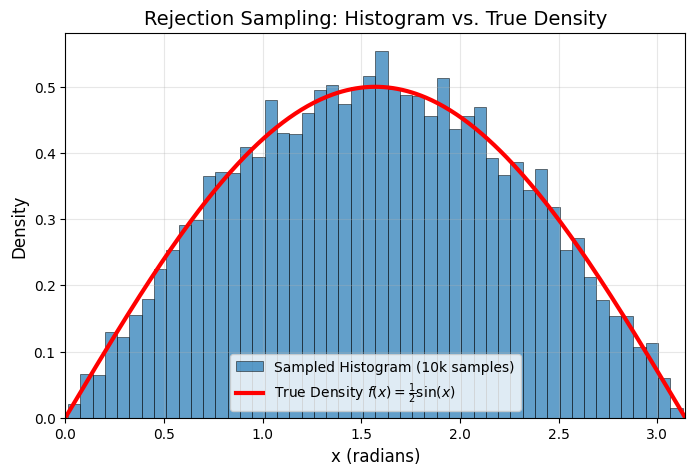

In [17]:
f = lambda x: 0.5 * np.sin(x)
x_domain = np.linspace(0, np.pi, 400)
y_true = f(x_domain)

# 2. Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# 3. Plot the normalized histogram of samples
ax.hist(accepted_samples, bins=50, density=True, 
        label='Sampled Histogram (10k samples)', 
        alpha=0.7, edgecolor='k', linewidth=0.5)

# 4. Overlay the true density function
ax.plot(x_domain, y_true, 'r-', linewidth=3, 
        label=r'True Density $f(x) = \frac{1}{2}\sin(x)$')

# 5. Add labels, title, and grid
ax.set_xlabel('x (radians)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Rejection Sampling: Histogram vs. True Density', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, np.pi)

# 6. Save and show the plot
plt.savefig('q6d_histogram.png', dpi=150, bbox_inches='tight')
plt.show()